In [19]:
#code snippet 1
import pandas as pd
import numpy as np
# Specify the path to your CSV file
url = 'https://docs.google.com/spreadsheets/d/1XSBE7VwTJ-xB300r2JAwZesaAbGTLvMgS4qRxXfDjys/pub?gid=0&single=true&output=csv'
# Read the CSV file into a pandas DataFrame
data = pd.read_csv(url)
data.shape
# Display the first few rows of the DataFrame to verify
display(data.head())

,Customer ID,Title,First Name,Middle Name,Last Name,Suffix,Street Address1,Street Address2,City-ZipCode-State,Birth Date,...,Occupation,Gender,Marital Status,Home Owner Status,Number of Cars Owned,Number of Children At Home,Total Number of Children,Annual Income,Avg Monthly Spend,eBook Subscriber Flag
0,11000,NaN,Jon,V,Yang,NaN,3761 N. 14th St,NaN,Cleveland-44101-Ohio,4/8/66,...,Professional,M,M,1,0,0,2,137947,89,0
1,11001,NaN,Eugene,L,Huang,NaN,2243 W St.,NaN,Seattle-98101-Washington,5/14/65,...,Professional,M,S,0,1,3,3,101141,117,1
2,11002,NaN,Ruben,NaN,Torres,NaN,5844 Linden Land,NaN,Omaha-68101-Nebraska,8/12/65,...,Professional,M,M,1,1,3,3,91945,123,0
3,11003,NaN,Christy,NaN,Zhu,NaN,1825 Village Pl.,NaN,Fort Worth-76101-Texas,2/15/68,...,Professional,F,S,0,1,0,0,86688,50,0
4,11004,NaN,Elizabeth,NaN,Johnson,NaN,7553 Harness Circle,NaN,Oakland-94601-California,8/8/68,...,Professional,F,S,1,4,5,5,92771,95,1


In [20]:
#code snippet 2
#missimng more than 20 % data
#drop Title, Middle Name, Suffix, Street Address2
data80=data.drop(['Title', 'Middle Name', 'Suffix', 'Street Address2'], axis=1)
data80.dtypes

,0
Customer ID,int64
First Name,object
Last Name,object
Street Address1,object
City-ZipCode-State,object
Birth Date,object
Education Level,object
Occupation,object
Gender,object
Marital Status,object


In [21]:
#code snippet 3
#qualitative data preparation
# Setting Zip, eBook Subscriber Flag as a string variable
data80['Home Owner Status'] = data80['Home Owner Status'].astype(str)
data80['eBook Subscriber Flag'] = data80['eBook Subscriber Flag'].astype(str)
#remove noise varaibles:
dataq=data80.drop(['Customer ID', 'First Name', 'Last Name', 'Street Address1'], axis=1)
#separate City-ZipCode-State into 3 varaibles:
dataq[['City', 'ZipCode', 'State']]=dataq['City-ZipCode-State'].str.split('-', expand=True)
#drop City-ZipCode-State, remove noise variable zip
dataq=dataq.drop(['City-ZipCode-State'], axis=1)
dataq

,Birth Date,Education Level,Occupation,Gender,Marital Status,Home Owner Status,Number of Cars Owned,Number of Children At Home,Total Number of Children,Annual Income,Avg Monthly Spend,eBook Subscriber Flag,City,ZipCode,State
0,4/8/66,Bachelors,Professional,M,M,1,0,0,2,137947,89,0,Cleveland,44101,Ohio
1,5/14/65,Bachelors,Professional,M,S,0,1,3,3,101141,117,1,Seattle,98101,Washington
2,8/12/65,Bachelors,Professional,M,M,1,1,3,3,91945,123,0,Omaha,68101,Nebraska
3,2/15/68,Bachelors,Professional,F,S,0,1,0,0,86688,50,0,Fort Worth,76101,Texas
4,8/8/68,Bachelors,Professional,F,S,1,4,5,5,92771,95,1,Oakland,94601,California
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16514,3/22/65,Bachelors,Professional,F,M,1,4,5,5,101542,101,0,San Antonio,78201,Texas
16515,4/2/36,Partial College,Professional,F,S,1,2,0,3,46549,46,0,Pittsburgh,15201,Pennsylvania
16516,1/1/40,Bachelors,Management,M,M,1,2,0,5,133053,79,0,Honolulu,96801,Hawaii
16517,10/20/46,High School,Skilled Manual,M,M,1,2,0,4,31930,65,0,Anaheim,92801,California


In [22]:
#Feature Engineering
#derive age from Birth Date
from datetime import datetime
import numpy as np
import pandas as pd # Ensure pandas is imported for pd.NA

today = datetime.now()
# Convert 'Birth Date' to datetime objects with explicit format
dataq['Birth Date'] = pd.to_datetime(dataq['Birth Date'], format='%m/%d/%y')

# Correct birth years that are in the future due to two-digit year interpretation
# If a birth year is after the current year, subtract 100 years
dataq.loc[dataq['Birth Date'].dt.year > today.year, 'Birth Date'] -= pd.offsets.DateOffset(years=100)

# Calculate age based on current date, using only the year part
dataq['Age'] = today.year - dataq['Birth Date'].dt.year

# Filter dataq where 'Birth Date' is less than or equal to today
dataq_filtered = dataq[dataq['Birth Date'] <= today]

#drop 'Birth Date' remove redundant variable
predictor=dataq_filtered.drop(['Birth Date'], axis=1)

# Ensure 'eBook Subscriber Flag' is numeric before comparison
# It should remain an integer type for future aggregations
predictor['eBook Subscriber Flag'] = predictor['eBook Subscriber Flag'].astype(int)

#derive esubscribey from eBook Subscriber Flag ==1, otherwise NaN
predictor['esubscribey'] = np.where(predictor['eBook Subscriber Flag'] == 1, 1, pd.NA)

#drop esubscribey,this was created for Tableau visualization
predictor=predictor.drop(['esubscribey'], axis=1)
# Display the first few rows with the new 'Age' and 'esubscribey' columns
display(predictor.head())

,Education Level,Occupation,Gender,Marital Status,Home Owner Status,Number of Cars Owned,Number of Children At Home,Total Number of Children,Annual Income,Avg Monthly Spend,eBook Subscriber Flag,City,ZipCode,State,Age
0,Bachelors,Professional,M,M,1,0,0,2,137947,89,0,Cleveland,44101,Ohio,59
1,Bachelors,Professional,M,S,0,1,3,3,101141,117,1,Seattle,98101,Washington,60
2,Bachelors,Professional,M,M,1,1,3,3,91945,123,0,Omaha,68101,Nebraska,60
3,Bachelors,Professional,F,S,0,1,0,0,86688,50,0,Fort Worth,76101,Texas,57
4,Bachelors,Professional,F,S,1,4,5,5,92771,95,1,Oakland,94601,California,57


In [23]:
predictor.shape

(16518, 15)

In [24]:
#code snippet 6
# Installing Dython for statistical correlations and significance tests
!pip install Dython

In [25]:
# Code snippet 7
# Importing relevant statistical modules
from dython.nominal import associations

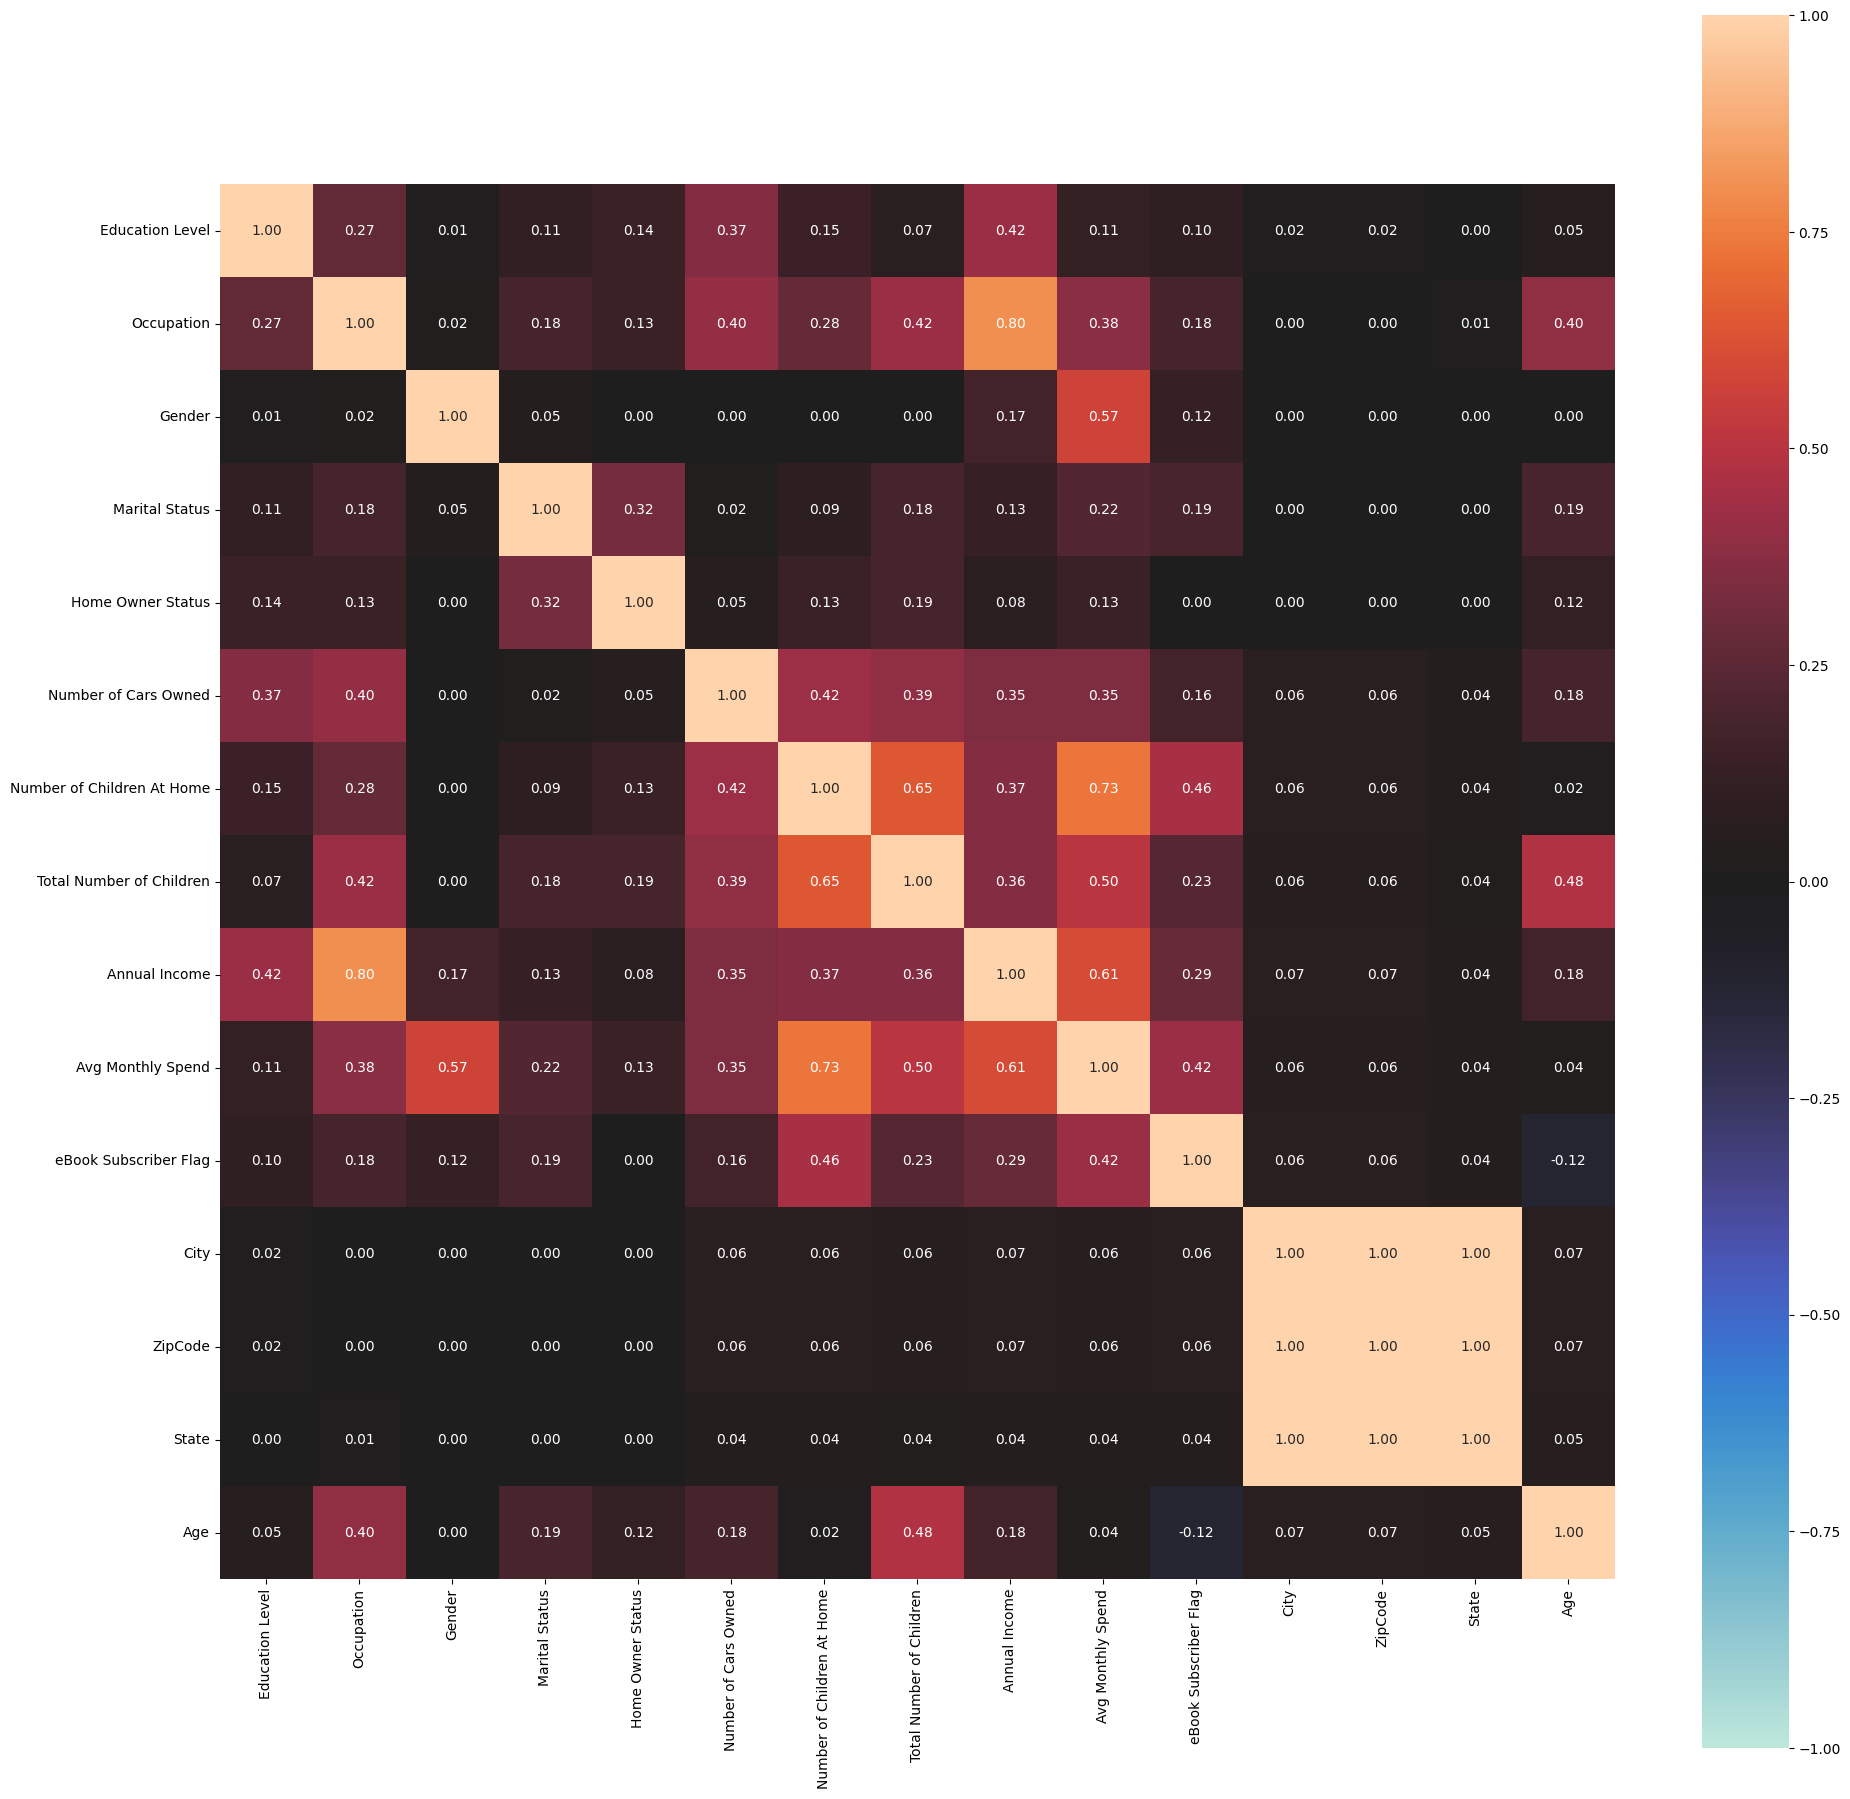

In [26]:
# Code snippet 8
# Running the association functions on the predictor variables
assoc = associations(predictor)

In [27]:
#code snippet 9.5
#drop City, remove redundant variable city for Zipcode(data has 1. unique values of zip/city,2.equal positive correlation to target varaible-> keep Zipcode as it has more granuality)
predictor=predictor.drop(['City', 'State'], axis=1)
#ignored 'eBook Subscriber Flag' for Dependent varaible1 "Avg Monthly Spend"
predictor1=predictor.drop(['eBook Subscriber Flag'], axis=1)
#ignored 'Avg Monthly Spend' for Dependent varaible2 "eBook Subscriber Flag"
predictor2=predictor.drop(['Avg Monthly Spend'], axis=1)
#drop 'Total Number of Children', remove this variable as it has very strong correlation to Number of Children At Home)
#predictor=predictor.drop(['Total Number of Children'], axis=1)

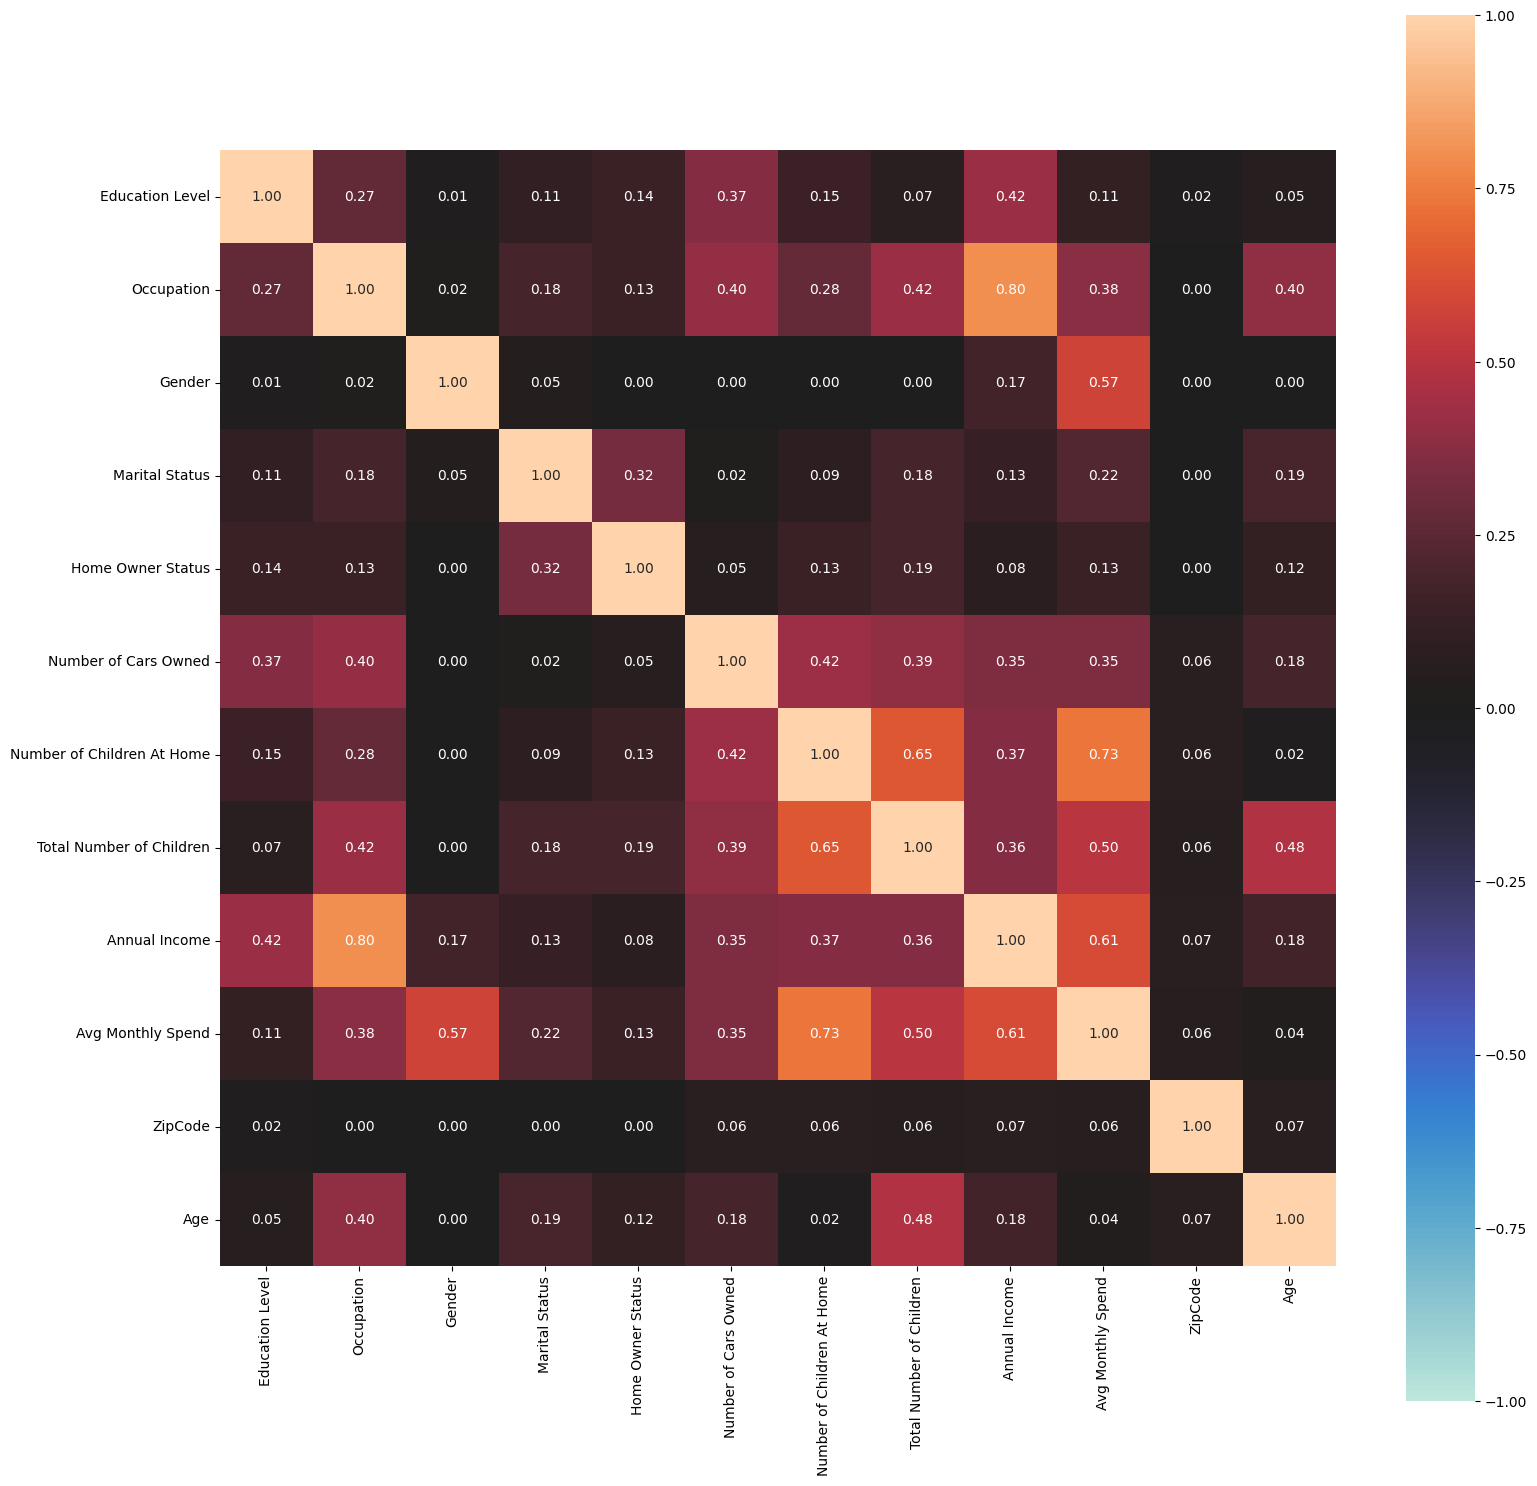

In [28]:
# Code snippet 9.75
# Running the association functions on the final predictor variables for Depenedent varable 'Avg Monthly Spend'
assoc = associations(predictor1)

In [29]:
# Code snippet 10
# Storing the association values in a matrix
assoc_matrix = assoc['corr']

In [30]:
# Code snippet 11
# Setting the target variable 'Avg Monthly Spend'
target = 'Avg Monthly Spend'

In [31]:
# Code snippet 12
# List the associated variables in the descending order of influence on the target variable
assoc_matrix[target].abs().sort_values(ascending=False)

,Avg Monthly Spend
Avg Monthly Spend,1.000000
Number of Children At Home,0.730415
Annual Income,0.607743
Gender,0.571727
Total Number of Children,0.500367
Occupation,0.381425
Number of Cars Owned,0.346605
Marital Status,0.218827
Home Owner Status,0.134304
Education Level,0.112509


In [32]:
#code snipper 13
numeric_features = []
character_features = []

for col in predictor1.columns:
    if predictor1[col].dtype == 'object':
        character_features.append(col)
    else:
        numeric_features.append(col)

print("Numeric Features:", numeric_features)
print("Character Features:", character_features)

Numeric Features: ['Number of Cars Owned', 'Number of Children At Home', 'Total Number of Children', 'Annual Income', 'Avg Monthly Spend', 'Age']
Character Features: ['Education Level', 'Occupation', 'Gender', 'Marital Status', 'Home Owner Status', 'ZipCode']


In [33]:
print("Correlation signs with target variable 'Avg Monthly Spend':")
print(assoc_matrix[target].sort_values(ascending=False))

Correlation signs with target variable 'Avg Monthly Spend':
Avg Monthly Spend             1.000000
Number of Children At Home    0.730415
Annual Income                 0.607743
Gender                        0.571727
Total Number of Children      0.500367
Occupation                    0.381425
Number of Cars Owned          0.346605
Marital Status                0.218827
Home Owner Status             0.134304
Education Level               0.112509
ZipCode                       0.062211
Age                           0.037866
Name: Avg Monthly Spend, dtype: float64


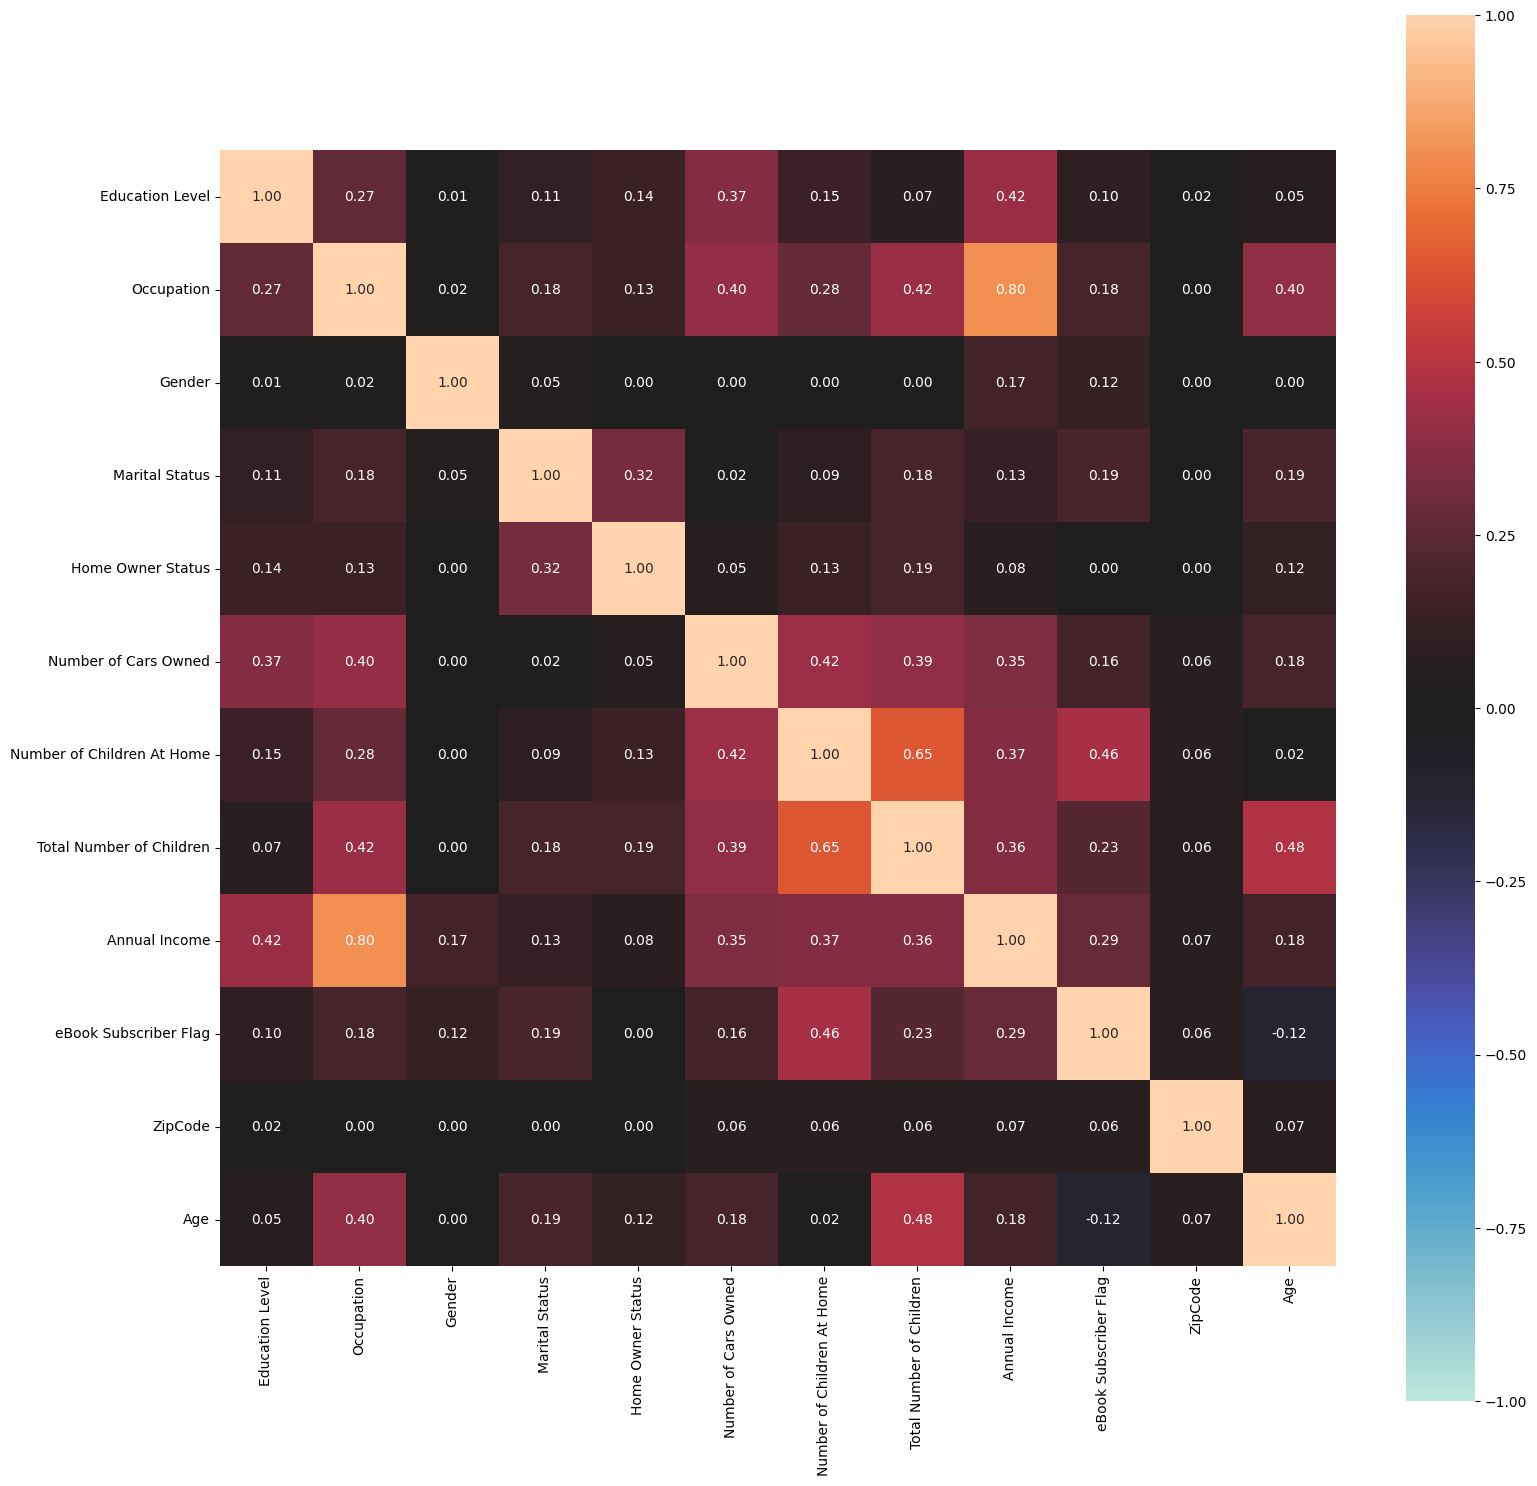

In [34]:
# Code snippet 13.5
# Running the association functions on the final predictor variable for Depenedent varable 'eBook Subscriber Flag'
assoc = associations(predictor2)

In [35]:
# Code snippet 14
# Setting the target variable 'eBook Subscriber Flag'
target = 'eBook Subscriber Flag'

In [36]:
# Code snippet 14.5
# Storing the association values in a matrix
assoc_matrix = assoc['corr']

In [37]:
# Code snippet 15
# List the associated variables in the descending order of influence on the target variable
assoc_matrix[target].abs().sort_values(ascending=False)

,eBook Subscriber Flag
eBook Subscriber Flag,1.000000
Number of Children At Home,0.456361
Annual Income,0.287137
Total Number of Children,0.233569
Marital Status,0.192926
Occupation,0.181265
Number of Cars Owned,0.164706
Age,0.124627
Gender,0.120031
Education Level,0.101012


In [38]:
#code snipper 14
numeric_features = []
character_features = []

for col in predictor2.columns:
    if predictor2[col].dtype == 'object':
        character_features.append(col)
    else:
        numeric_features.append(col)

print("Numeric Features:", numeric_features)
print("Character Features:", character_features)

Numeric Features: ['Number of Cars Owned', 'Number of Children At Home', 'Total Number of Children', 'Annual Income', 'eBook Subscriber Flag', 'Age']
Character Features: ['Education Level', 'Occupation', 'Gender', 'Marital Status', 'Home Owner Status', 'ZipCode']


In [39]:
# Display the correlation signs with the target variable 'eBook Subscriber Flag'
print("Correlation signs with target variable 'eBook Subscriber Flag':")
print(assoc_matrix[target].sort_values(ascending=False))

Correlation signs with target variable 'eBook Subscriber Flag':
eBook Subscriber Flag         1.000000
Number of Children At Home    0.456361
Annual Income                 0.287137
Total Number of Children      0.233569
Marital Status                0.192926
Occupation                    0.181265
Number of Cars Owned          0.164706
Gender                        0.120031
Education Level               0.101012
ZipCode                       0.063061
Home Owner Status             0.000582
Age                          -0.124627
Name: eBook Subscriber Flag, dtype: float64
